In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    parse_dates={'datetime': ['Date','Time']},
    infer_datetime_format=True,
    low_memory=False,
    na_values=['?']
)

# Set datetime as index
df.set_index('datetime', inplace=True)

# Convert numeric columns
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['Global_reactive_power'] = pd.to_numeric(df['Global_reactive_power'], errors='coerce')
df['Voltage'] = pd.to_numeric(df['Voltage'], errors='coerce')
df['Global_intensity'] = pd.to_numeric(df['Global_intensity'], errors='coerce')
df['Sub_metering_1'] = pd.to_numeric(df['Sub_metering_1'], errors='coerce')
df['Sub_metering_2'] = pd.to_numeric(df['Sub_metering_2'], errors='coerce')
df['Sub_metering_3'] = pd.to_numeric(df['Sub_metering_3'], errors='coerce')

# Forward fill missing values
df.fillna(method='ffill', inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


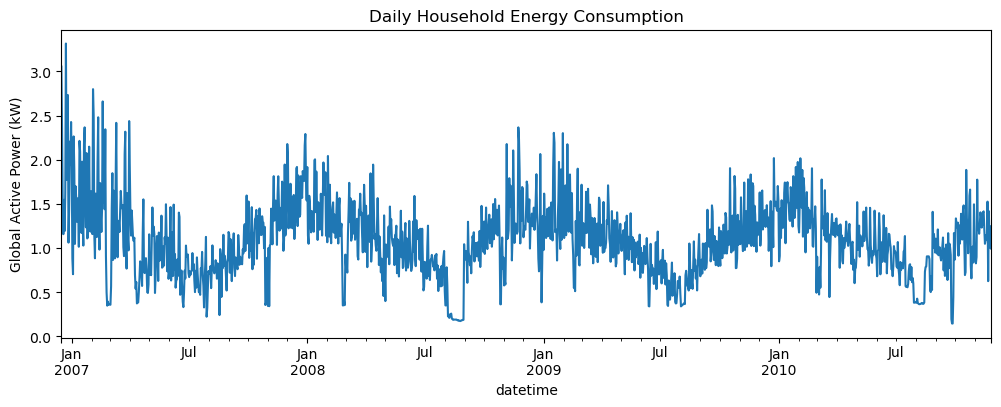

In [6]:
daily_data = df['Global_active_power'].resample('D').mean()

# Plot daily consumption
plt.figure(figsize=(12,4))
daily_data.plot()
plt.title("Daily Household Energy Consumption")
plt.ylabel("Global Active Power (kW)")
plt.show()

In [7]:
data = daily_data.to_frame().reset_index()
data['day_of_week'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['weekend'] = (data['day_of_week'] >= 5).astype(int)

# Lag features (past 7 days)
for lag in range(1,8):
    data[f'lag_{lag}'] = data['Global_active_power'].shift(lag)

# Drop NaN rows
data.dropna(inplace=True)

data.head()

,datetime,Global_active_power,day_of_week,month,day,weekend,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
7,2006-12-23,3.314851,5,12,23,1,1.625929,1.192439,1.545658,1.157079,1.530435,2.354486,3.053475
8,2006-12-24,1.770842,6,12,24,1,3.314851,1.625929,1.192439,1.545658,1.157079,1.530435,2.354486
9,2006-12-25,1.904944,0,12,25,0,1.770842,3.314851,1.625929,1.192439,1.545658,1.157079,1.530435
10,2006-12-26,2.732021,1,12,26,0,1.904944,1.770842,3.314851,1.625929,1.192439,1.545658,1.157079
11,2006-12-27,1.061639,2,12,27,0,2.732021,1.904944,1.770842,3.314851,1.625929,1.192439,1.545658


In [8]:
train_size = int(len(data) * 0.8)
train = data.iloc[:train_size]
test = data.iloc[train_size:]

X_train = train.drop(columns=['Global_active_power','datetime'])
y_train = train['Global_active_power']
X_test = test.drop(columns=['Global_active_power','datetime'])
y_test = test['Global_active_power']

ARIMA MAE: 0.36517602442388186
ARIMA RMSE: 0.4486927140187422


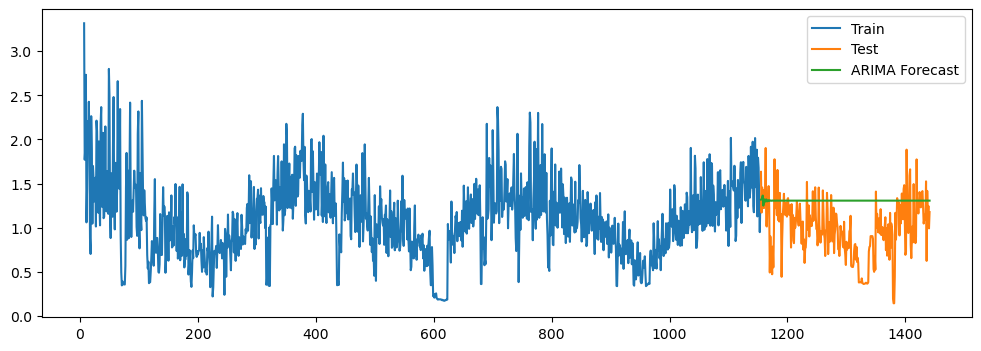

In [9]:
# Fit ARIMA
arima_model = ARIMA(train['Global_active_power'], order=(5,1,0))
arima_fit = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))

# Evaluate
mae_arima = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

# Plot
plt.figure(figsize=(12,4))
plt.plot(train['Global_active_power'], label='Train')
plt.plot(test['Global_active_power'], label='Test')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.legend()
plt.show()

02:07:08 - cmdstanpy - INFO - Chain [1] start processing
02:07:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 0.20190889153218405
Prophet RMSE: 0.2761190790233316


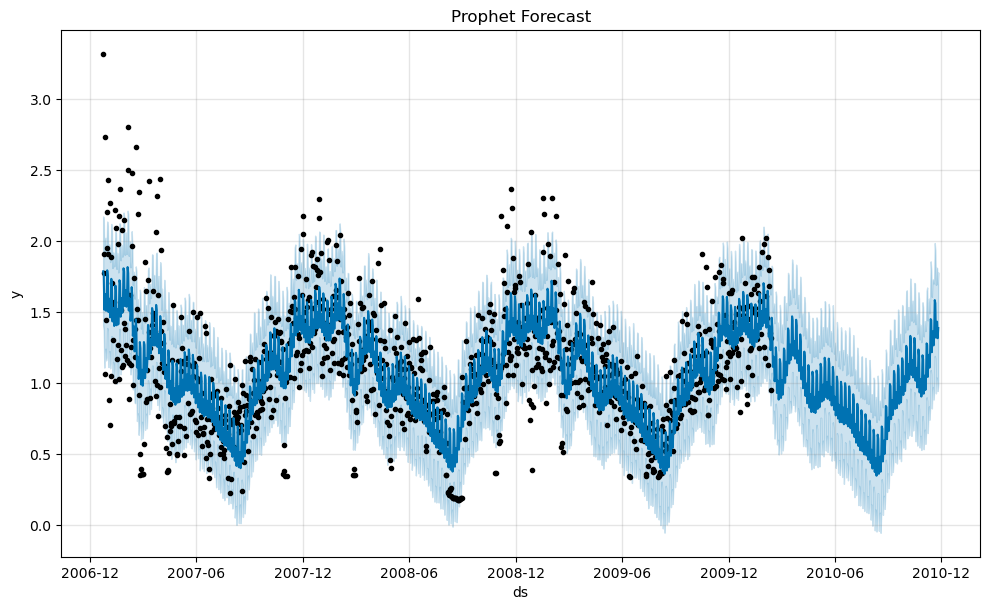

In [10]:
prophet_df = train[['datetime','Global_active_power']].rename(columns={'datetime':'ds','Global_active_power':'y'})
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_df)

# Make future dataframe
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

# Evaluation
y_pred_prophet = forecast['yhat'][-len(test):].values
mae_prophet = mean_absolute_error(y_test, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_test, y_pred_prophet))
print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)

# Plot
prophet_model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

XGBoost MAE: 0.18349030010063203
XGBoost RMSE: 0.24392727148537585


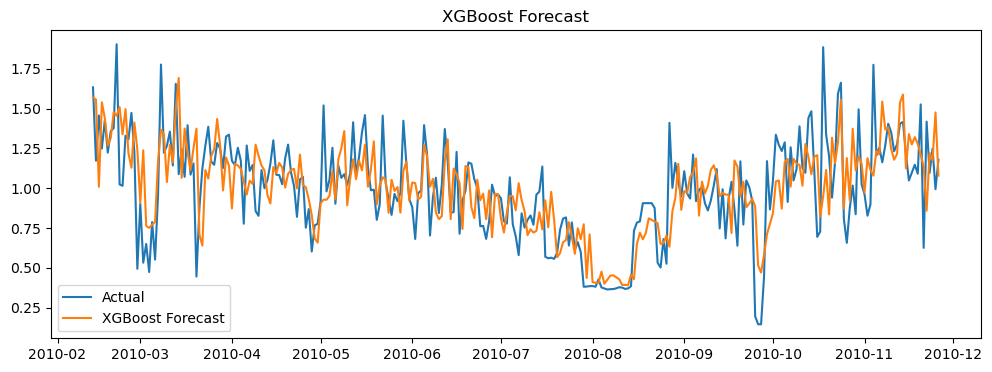

In [11]:
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

# Plot
plt.figure(figsize=(12,4))
plt.plot(test['datetime'], y_test, label='Actual')
plt.plot(test['datetime'], xgb_pred, label='XGBoost Forecast')
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

In [12]:
comparison = pd.DataFrame({
    'Model': ['ARIMA','Prophet','XGBoost'],
    'MAE':[mae_arima, mae_prophet, mae_xgb],
    'RMSE':[rmse_arima, rmse_prophet, rmse_xgb]
})
print(comparison)

     Model       MAE      RMSE
0    ARIMA  0.365176  0.448693
1  Prophet  0.201909  0.276119
2  XGBoost  0.183490  0.243927


## Insights & Conclusion

1. Model Comparison:
   - ARIMA: MAE=0.365, RMSE=0.449 → captures trends but misses short-term variations
   - Prophet: MAE=0.202, RMSE=0.276 → captures trend & seasonality
   - XGBoost: MAE=0.183, RMSE=0.244 → best performance due to lag and time features

2. Observations from plots:
   - XGBoost forecasts closely match actual energy usage
   - Prophet captures weekly/daily patterns
   - ARIMA lags during spikes

3. Recommendations:
   - Use XGBoost for short-term operational forecasts
   - Use Prophet for long-term planning
   - ARIMA can be a baseline
   - Include time-based and lag features for better accuracy